In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import os.path as op
import yaml
import pandas as pd

In [2]:


def read_all_results_yaml(root_dir, select = ('netmap_config.yaml', 'netmap_config_1.yaml')):
    """
    Reads all YAML files in a directory tree starting from root_dir, processes
    the nested structure (including multiple top-level keys), and concatenates
    the results into a single DataFrame.

    Args:
        root_dir (str): The path to the root directory.
        select (tuple or str): File extension or full filename to select.
                               Defaults to common YAML configuration names.

    Returns:
        pandas.DataFrame: A DataFrame containing the processed data from all YAML files.
                          Returns an empty DataFrame if no files are found or an error occurs.
    """
    all_results_dfs = []

    # Normalize the root_dir path
    root_dir = os.path.abspath(root_dir)

    # Check if the root directory exists
    if not os.path.isdir(root_dir):
        print(f"Error: Directory '{root_dir}' not found.")
        return pd.DataFrame() # Return an empty DataFrame

    if isinstance(select, str):
        select = (select,)

    for dirpath, dirnames, filenames in os.walk(root_dir):
        print(dirpath)
        for filename in filenames:
            # Check if the filename ends with any of the selected strings/extensions
            print(filename)
            if any(filename.endswith(s) for s in select):
                filepath = op.join(dirpath, filename)
                print(f"Processing: {filepath}")

                try:
                    with open(filepath, 'r') as f:
                        yaml_content = yaml.safe_load(f)

                    if not yaml_content or not isinstance(yaml_content, dict):
                        continue # Skip empty or invalid YAML file

                    # The directory one level up is 'CONFIG'
                    config_dir = op.basename(op.dirname(dirpath))
                    
                    # Iterate through all top-level keys (e.g., netmap_config_1, netmap_config_2, etc.)
                    for config_key, nested_data in yaml_content.items():
                        
                        if not isinstance(nested_data, dict):
                            print(f"Skipping key '{config_key}' in {filename}: not a dictionary.")
                            continue

                        records = []
                        
                        # Extract common metadata for this configuration key
                        clustering_score = nested_data.get('clustering_score')
                        total_number_edges = nested_data.get('total_number_edges')

                        # Iterate through the network-specific keys (like net_53_1113)
                        for net_key, net_data in nested_data.items():
                            
                            # Skip known non-network metadata fields
                            if net_key in ['clustering_score', 'total_number_edges']:
                                continue
                            
                            if not isinstance(net_data, dict):
                                print(f"Skipping network key '{net_key}' under '{config_key}': not a dictionary.")
                                continue

                            # Create a record for the DataFrame
                            record = {
                                'net_name': net_key,           # e.g., net_53_1113
                                'config_key': config_key,      # e.g., netmap_config_1
                                'filename': filename,
                                # Add the common metadata
                                'clustering_score': clustering_score,
                                'total_number_edges': total_number_edges,
                            }
                            # Add the network-specific data (edge_overlap, net_size, etc.)
                            record.update(net_data)
                            
                            records.append(record)

                        # Create a DataFrame from the extracted records for this config_key
                        if records:
                            net_dir = op.basename(dirpath)  
                            # The directory one level up is 'CONFIG'
                            config_dir = op.basename(op.dirname(dirpath))
                        


                            overlaps_df = pd.DataFrame(records)
                            # Add the directory name (similar to your original 'net' column)
                            overlaps_df['algorithm'] = op.basename(op.dirname(op.dirname(op.dirname(filepath))))
                            overlaps_df['config'] = op.basename(op.dirname(op.dirname(filepath)))

                            overlaps_df['dataset'] = op.basename(op.dirname(filepath))
                            overlaps_df['config_dir'] = config_dir
                            all_results_dfs.append(overlaps_df)


                except Exception as e:
                    print(f"Error reading or processing {filepath}: {e}")
                    continue

    if all_results_dfs:
        # Concatenate all DataFrames into one
        all_results = pd.concat(all_results_dfs, ignore_index=True)
    else:
        all_results = pd.DataFrame()

    all_results['n_clusters'] = all_results['config_dir'].apply(recode_number_of_datasets)


    return all_results

def recode_number_of_datasets(config_item):
    if config_item == 'config_easy':
        return 2
    if config_item == 'config_noise':
        return 2
    if config_item == 'config_three':
        return 3
    if config_item == 'config_three_noise':
        return 3
    if config_item == 'config_five':
        return 5
    if config_item == 'config_ten':
        return 10


In [3]:
df_results_leiden = read_all_results_yaml('/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries_final_benchmark/', select=('clustering_score.json'))
df_results_leiden.to_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/data/clustering_scores_leiden.tsv', sep = '\t', index=False)


/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries_final_benchmark
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries_final_benchmark/grnboost2
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries_final_benchmark/grnboost2/config_easy
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries_final_benchmark/grnboost2/config_easy/net_133_10773_net_82_10152_net_72_10551
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries_final_benchmark/grnboost2/config_easy/net_133_10773_net_82_10152_net_72_10551/config_easy
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries_final_benchmark/grnboost2/config_easy/net_133_10773_net_82_10152_net_72_10551/config_easy/net_133_10773_net_82_10152_net_72_10551
preclustered_overlaps_global_top_k.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries_final_benchmark/grnboost2/config_easy/net_172_10626_net_89_11634_net_76_10367
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries_final_ben

In [4]:
df_results_leiden

,net_name,config_key,filename,clustering_score,total_number_edges,edge_overlap,net_size,overlap_percent,reverse_overlap_percent,algorithm,config,dataset,config_dir,n_clusters
0,net_133_10773,GradientShap_64_1_0.1_NegativeBinomialAutoenco...,GradientShap_64_1_0.1_NegativeBinomialAutoenco...,1.000000,82369,201,201,1.0,1.0,netmap,config_easy,net_133_10773_net_82_10152_net_72_10551,config_easy,2
1,net_82_10152,GradientShap_64_1_0.1_NegativeBinomialAutoenco...,GradientShap_64_1_0.1_NegativeBinomialAutoenco...,1.000000,82369,164,164,1.0,1.0,netmap,config_easy,net_133_10773_net_82_10152_net_72_10551,config_easy,2
2,net_172_10626,GradientShap_64_1_0.1_NegativeBinomialAutoenco...,GradientShap_64_1_0.1_NegativeBinomialAutoenco...,1.000000,113569,239,239,1.0,1.0,netmap,config_easy,net_172_10626_net_89_11634_net_76_10367,config_easy,2
3,net_89_11634,GradientShap_64_1_0.1_NegativeBinomialAutoenco...,GradientShap_64_1_0.1_NegativeBinomialAutoenco...,1.000000,113569,98,98,1.0,1.0,netmap,config_easy,net_172_10626_net_89_11634_net_76_10367,config_easy,2
4,net_53_11196,GradientShap_64_1_0.1_NegativeBinomialAutoenco...,GradientShap_64_1_0.1_NegativeBinomialAutoenco...,1.000000,42849,78,78,1.0,1.0,netmap,config_easy,net_53_11196_net_70_11431_net_84_9903,config_easy,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,net_60_10082,scgenerai,scgenerai_clustering_score.json,0.865333,101124,104,104,1.0,1.0,scgenerai,config_three_noise,net_70_11431_net_60_10082_net_135_11054_net_53...,config_three_noise,3
181,net_70_11431,scgenerai,scgenerai_clustering_score.json,0.865333,101124,88,88,1.0,1.0,scgenerai,config_three_noise,net_70_11431_net_60_10082_net_135_11054_net_53...,config_three_noise,3
182,net_59_10488,scgenerai,scgenerai_clustering_score.json,0.865333,107584,87,87,1.0,1.0,scgenerai,config_three_noise,net_70_11431_net_84_9903_net_59_10488_net_115_...,config_three_noise,3
183,net_70_11431,scgenerai,scgenerai_clustering_score.json,0.865333,107584,88,88,1.0,1.0,scgenerai,config_three_noise,net_70_11431_net_84_9903_net_59_10488_net_115_...,config_three_noise,3


In [5]:


def plot_clustering_score_boxplot(
    df,
    n_clusters_col="n_clusters",
    score_col="clustering_score",
    algorithm_col="algorithm",
    ax=None,
    figsize=(8, 5),
):
    """Boxplot of clustering score vs. number of clusters, grouped by algorithm.

    Args:
        df (pd.DataFrame): One row per run, with columns ``n_clusters_col``,
            ``score_col``, ``algorithm_col``.
        n_clusters_col (str): Column with the number of clusters (x-axis).
            Defaults to ``'n_clusters'``.
        score_col (str): Column with the clustering score (y-axis). Defaults
            to ``'score'``.
        algorithm_col (str): Column with the algorithm label (hue). Defaults
            to ``'algorithm'``.
        ax (matplotlib.axes.Axes, optional): Axes to draw on. A new figure is
            created if ``None`` (default).
        figsize (tuple): Figure size, only used when ``ax`` is ``None``.
            Defaults to ``(8, 5)``.

    Returns:
        tuple: ``(fig, ax)``.
    """
    algorithms = list(pd.unique(df[algorithm_col]))
    if len(algorithms) > len(_CATEGORICAL_PALETTE):
        raise ValueError(
            f"{len(algorithms)} algorithms but only {len(_CATEGORICAL_PALETTE)} "
            "categorical colors are validated as colorblind-safe together; fold "
            "some algorithms into 'Other' or split into facets."
        )
    palette = dict(zip(algorithms, _CATEGORICAL_PALETTE))

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    sns.boxplot(
        data=df, x=n_clusters_col, y=score_col, hue=algorithm_col,
        order=sorted(df[n_clusters_col].unique()), hue_order=algorithms,
        palette=palette, ax=ax, linewidth=1.0, fliersize=2,
    )

    sns.despine(ax=ax)
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.set_xlabel("Number of clusters")
    ax.set_ylabel("Clustering score")
    ax.legend(title=algorithm_col, loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False)

    return fig, ax

_CATEGORICAL_PALETTE = [
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100",
    "#e87ba4", "#008300", "#4a3aa7", "#e34948",
]


(<Figure size 800x500 with 1 Axes>,
 <Axes: xlabel='Number of clusters', ylabel='Clustering score'>)

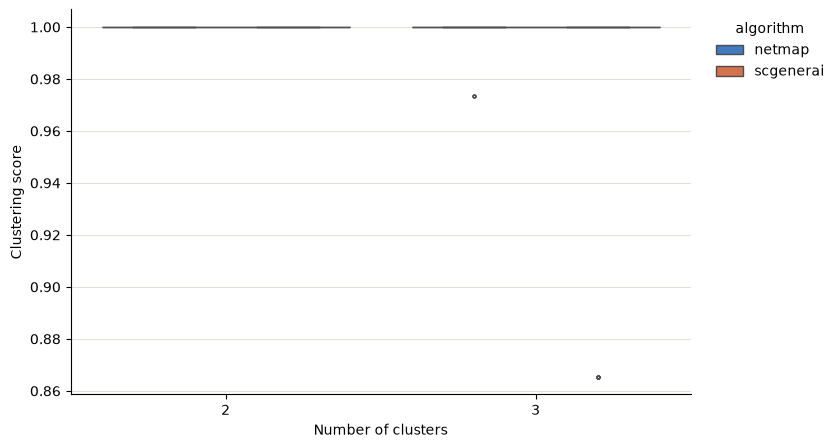

In [6]:
plot_clustering_score_boxplot(df_results_leiden)

In [7]:


def plot_clustering_score_boxplot(
    df,
    n_clusters_col="n_clusters",
    score_col="clustering_score",
    algorithm_col="algorithm",
    ax=None,
    figsize=(8, 5),
):
    """Boxplot of clustering score vs. number of clusters, grouped by algorithm.

    Args:
        df (pd.DataFrame): One row per run, with columns ``n_clusters_col``,
            ``score_col``, ``algorithm_col``.
        n_clusters_col (str): Column with the number of clusters (x-axis).
            Defaults to ``'n_clusters'``.
        score_col (str): Column with the clustering score (y-axis). Defaults
            to ``'score'``.
        algorithm_col (str): Column with the algorithm label (hue). Defaults
            to ``'algorithm'``.
        ax (matplotlib.axes.Axes, optional): Axes to draw on. A new figure is
            created if ``None`` (default).
        figsize (tuple): Figure size, only used when ``ax`` is ``None``.
            Defaults to ``(8, 5)``.

    Returns:
        tuple: ``(fig, ax)``.
    """
    algorithms = list(pd.unique(df[algorithm_col]))
    if len(algorithms) > len(_CATEGORICAL_PALETTE):
        raise ValueError(
            f"{len(algorithms)} algorithms but only {len(_CATEGORICAL_PALETTE)} "
            "categorical colors are validated as colorblind-safe together; fold "
            "some algorithms into 'Other' or split into facets."
        )
    palette = dict(zip(algorithms, _CATEGORICAL_PALETTE))

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    sns.boxplot(
        data=df, x=n_clusters_col, y=score_col, hue=algorithm_col,
        order=sorted(df[n_clusters_col].unique()), hue_order=algorithms,
        palette=palette, ax=ax, linewidth=1.0, fliersize=2,
    )

    sns.despine(ax=ax)
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.set_xlabel("Number of clusters")
    ax.set_ylabel("Clustering score")
    ax.legend(title=algorithm_col, loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False)

    return fig, ax


In [8]:


def read_all_results_yaml(root_dir, select = ('netmap_config.yaml', 'netmap_config_1.yaml')):
    """
    Reads all YAML files in a directory tree starting from root_dir, processes
    the nested structure (including multiple top-level keys), and concatenates
    the results into a single DataFrame.

    Args:
        root_dir (str): The path to the root directory.
        select (tuple or str): File extension or full filename to select.
                               Defaults to common YAML configuration names.

    Returns:
        pandas.DataFrame: A DataFrame containing the processed data from all YAML files.
                          Returns an empty DataFrame if no files are found or an error occurs.
    """
    all_results_dfs = []

    # Normalize the root_dir path
    root_dir = os.path.abspath(root_dir)

    # Check if the root directory exists
    if not os.path.isdir(root_dir):
        print(f"Error: Directory '{root_dir}' not found.")
        return pd.DataFrame() # Return an empty DataFrame

    if isinstance(select, str):
        select = (select,)

    for dirpath, dirnames, filenames in os.walk(root_dir):
        for filename in filenames:

            filepath = op.join(dirpath, filename)
            print(f"Processing: {filepath}")

            try:
                with open(filepath, 'r') as f:
                    yaml_content = yaml.safe_load(f)

                if not yaml_content or not isinstance(yaml_content, dict):
                    continue # Skip empty or invalid YAML file

                # The directory one level up is 'CONFIG'
                config_dir = op.basename(op.dirname(dirpath))
                
                # Iterate through all top-level keys (e.g., netmap_config_1, netmap_config_2, etc.)
                for config_key, nested_data in yaml_content.items():
                    
                    if not isinstance(nested_data, dict):
                        print(f"Skipping key '{config_key}' in {filename}: not a dictionary.")
                        continue

                    records = []
                    
                    # Extract common metadata for this configuration key
                    clustering_score = nested_data.get('clustering_score')
                    total_number_edges = nested_data.get('total_number_edges')

                    # Iterate through the network-specific keys (like net_53_1113)
                    for net_key, net_data in nested_data.items():
                        
                        # Skip known non-network metadata fields
                        if net_key in ['clustering_score', 'total_number_edges']:
                            continue
                        
                        if not isinstance(net_data, dict):
                            print(f"Skipping network key '{net_key}' under '{config_key}': not a dictionary.")
                            continue

                        # Create a record for the DataFrame
                        record = {
                            'net_name': net_key,           # e.g., net_53_1113
                            'config_key': config_key,      # e.g., netmap_config_1
                            'filename': filename,
                            # Add the common metadata
                            'clustering_score': clustering_score,
                            'total_number_edges': total_number_edges,
                        }
                        # Add the network-specific data (edge_overlap, net_size, etc.)
                        record.update(net_data)
                        
                        records.append(record)
                    print(records)
                    # Create a DataFrame from the extracted records for this config_key
                    if records:
                        net_dir = op.basename(dirpath)  
                        # The directory one level up is 'CONFIG'
                        config_dir = op.basename(op.dirname(dirpath))
                    


                        overlaps_df = pd.DataFrame(records)
                        # Add the directory name (similar to your original 'net' column)
                        overlaps_df['dataset'] = op.basename(op.dirname(filepath))
                        overlaps_df['config_dir'] = config_dir
                        all_results_dfs.append(overlaps_df)


            except Exception as e:
                print(f"Error reading or processing {filepath}: {e}")
                continue

    if all_results_dfs:
        # Concatenate all DataFrames into one
        all_results = pd.concat(all_results_dfs, ignore_index=True)
    else:
        all_results = pd.DataFrame()

    all_results['n_clusters'] = all_results['config_dir'].apply(recode_number_of_datasets)


    return all_results

def recode_number_of_datasets(config_item):
    if config_item == 'config_easy':
        return 2
    if config_item == 'config_noise':
        return 2
    if config_item == 'config_three':
        return 3
    if config_item == 'config_three_noise':
        return 3
    if config_item == 'config_five':
        return 5
    if config_item == 'config_ten':
        return 10
